# Implementation of Convolutional Neural Network using Keras

**Course:** 6CS012 - Artificial Intelligence and Machine Learning  
**Worksheet:** 5  

## Objective
In this notebook, we will:
- Load and visualize images from directories
- Check and remove corrupted images
- Build training and validation datasets
- Create a CNN model using Keras
- Train the model with callbacks
- Evaluate the model
- Save and reload the model
- Make predictions and generate a classification report

In [40]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Imports

In [41]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report

# PATHS AND PARAMETERS


In [42]:
train_dir = r"/content/drive/MyDrive/AI_ML/Week5/FruitinAmazon/train/"
test_dir  = r"/content/drive/MyDrive/AI_ML/Week5/FruitinAmazon/test/"


## Task 1.1: Visualize one random image from each class

We will:
- Get all class directories from the training folder
- Randomly select one image from each class
- Display them in a grid with two rows

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


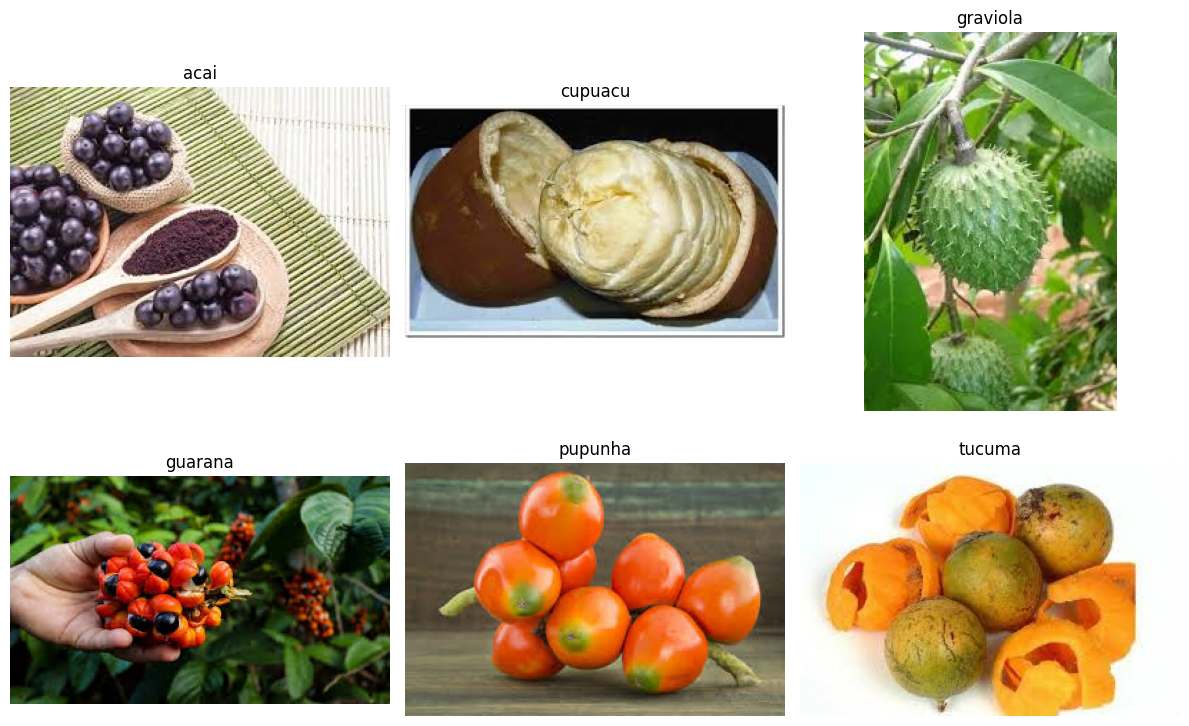

In [43]:
class_names = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

print("Classes found:", class_names)

selected_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.webp'))
    ]

    if len(images) > 0:
        random_image = random.choice(images)
        selected_images.append((class_name, os.path.join(class_path, random_image)))

num_images = len(selected_images)
num_rows = 2
num_cols = int(np.ceil(num_images / num_rows))

plt.figure(figsize=(4 * num_cols, 8))

for i, (class_name, image_path) in enumerate(selected_images):
    img = Image.open(image_path)

    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Observation
After visualizing the dataset, we can observe that:
- Each class is stored in its own folder.
- Images may have different backgrounds, lighting, angles, and sizes.
- This confirms that the dataset is suitable for image classification using CNN.

## Task 1.2: Check and remove corrupted images

The following code scans every image in every class folder.
If a corrupted image is found, it will be removed automatically.

In [44]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    for filename in os.listdir(class_path):
        image_path = os.path.join(class_path, filename)

        if not filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.webp')):
            continue

        try:
            with Image.open(image_path) as img:
                img.verify()   # checks if the image is valid
        except (IOError, SyntaxError, OSError):
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")
else:
    print(f"Total corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


## Task 2: Load and preprocess images

We will use `image_dataset_from_directory` to:
- Load images from folder structure
- Resize them to a fixed size
- Split training data into training and validation sets
- Normalize pixel values to the range [0, 1]

In [45]:
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2
seed = 123

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=seed
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=seed
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


Performance Optimization for Dataset Pipeline

In [46]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Task 3: Build CNN model

CNN structure:
- Conv2D layer with 32 filters and 3x3 kernel
- MaxPooling2D
- Conv2D layer with 32 filters and 3x3 kernel
- MaxPooling2D
- Flatten
- Dense layer with 64 neurons
- Dense layer with 128 neurons
- Output layer with `num_classes` neurons

In [47]:
model = keras.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Compile the model

We will use:
- Optimizer: Adam
- Loss: Sparse Categorical Crossentropy
- Metric: Accuracy

In [48]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Task 4: Train the model

We will train the model for up to 250 epochs, but use:
- ModelCheckpoint to save the best model
- EarlyStopping to stop training when validation loss stops improving

In [49]:
checkpoint_path = "/content/drive/MyDrive/AI_ML/Week5/best_cnn_model.h5"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=False,
        mode='max',
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=callbacks
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.2333 - loss: 1.9130
Epoch 1: val_accuracy improved from None to 0.00000, saving model to /content/drive/MyDrive/AI_ML/Week5/best_cnn_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/AI_ML/Week5/best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 603ms/step - accuracy: 0.2083 - loss: 1.9391 - val_accuracy: 0.0000e+00 - val_loss: 1.8255
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.1510 - loss: 1.8124
Epoch 2: val_accuracy improved from 0.00000 to 0.72222, saving model to /content/drive/MyDrive/AI_ML/Week5/best_cnn_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/AI_ML/Week5/best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 578ms/step - accuracy: 0.2083 - loss: 1.7206 - val_accuracy: 0.7222 - val_loss: 1.5102
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.4493 - loss: 1.5239
Epoch 3: val_accuracy improved from 0.72222 to 0.83333, saving model to /content/drive/MyDrive/AI_ML/Week5/best_cnn_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/AI_ML/Week5/best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 403ms/step - accuracy: 0.4861 - loss: 1.4720 - val_accuracy: 0.8333 - val_loss: 1.2093
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.6399 - loss: 1.2342
Epoch 4: val_accuracy improved from 0.83333 to 0.88889, saving model to /content/drive/MyDrive/AI_ML/Week5/best_cnn_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/AI_ML/Week5/best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 340ms/step - accuracy: 0.6944 - loss: 1.1329 - val_accuracy: 0.8889 - val_loss: 0.9552
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.7674 - loss: 0.9217
Epoch 5: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 312ms/step - accuracy: 0.8056 - loss: 0.8190 - val_accuracy: 0.7778 - val_loss: 0.8075
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.8361 - loss: 0.6342
Epoch 6: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 305ms/step - accuracy: 0.8889 - loss: 0.5263 - val_accuracy: 0.8889 - val_loss: 0.5160
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.8872 - loss: 0.3876
Epoch 7: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 331ms/step - accuracy: 0.9306 - loss: 0.3180 - val_accuracy: 0.8333 - val_loss: 0.3604
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 729m

## Task 5: Evaluate the model

Now we evaluate the trained model on the test dataset to measure final performance.

In [50]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7667 - loss: 0.7046
Test Loss: 0.7046
Test Accuracy: 0.7667


## Training and Validation Curves
We will visualize:
- Training vs Validation Accuracy
- Training vs Validation Loss

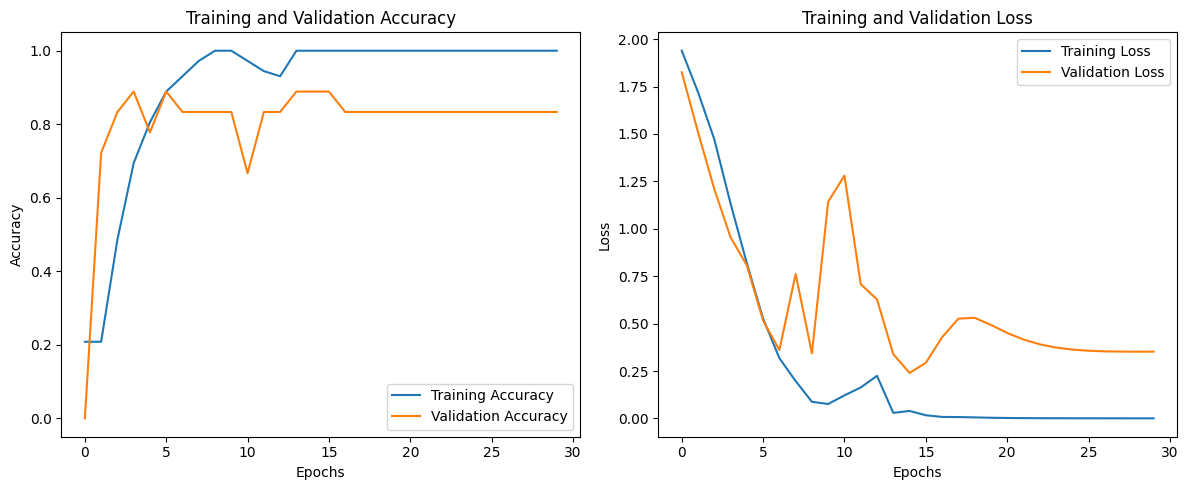

In [51]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Task 6: Save and load the model

We will:
- Save the trained model to an `.h5` file
- Load the model back
- Evaluate it again on the test set

In [52]:
model.save("/content/drive/MyDrive/AI_ML/Week5/final_cnn_model.h5")
print("Model saved successfully as final_cnn_model.h5")

Model saved successfully as final_cnn_model.h5


In [53]:
loaded_model = keras.models.load_model("/content/drive/MyDrive/AI_ML/Week5/final_cnn_model.h5")

loaded_loss, loaded_accuracy = loaded_model.evaluate(test_ds)
print(f"Loaded Model Test Loss: {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy: {loaded_accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.7667 - loss: 0.7046
Loaded Model Test Loss: 0.7046
Loaded Model Test Accuracy: 0.7667


## Task 7: Make predictions and generate classification report

We will:
- Predict class probabilities on the test set
- Convert probabilities to labels using `np.argmax()`
- Generate a classification report

In [54]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        acai       1.00      0.60      0.75         5
     cupuacu       0.50      1.00      0.67         5
    graviola       1.00      0.80      0.89         5
     guarana       0.71      1.00      0.83         5
     pupunha       1.00      0.80      0.89         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.77        30
   macro avg       0.87      0.77      0.77        30
weighted avg       0.87      0.77      0.77        30



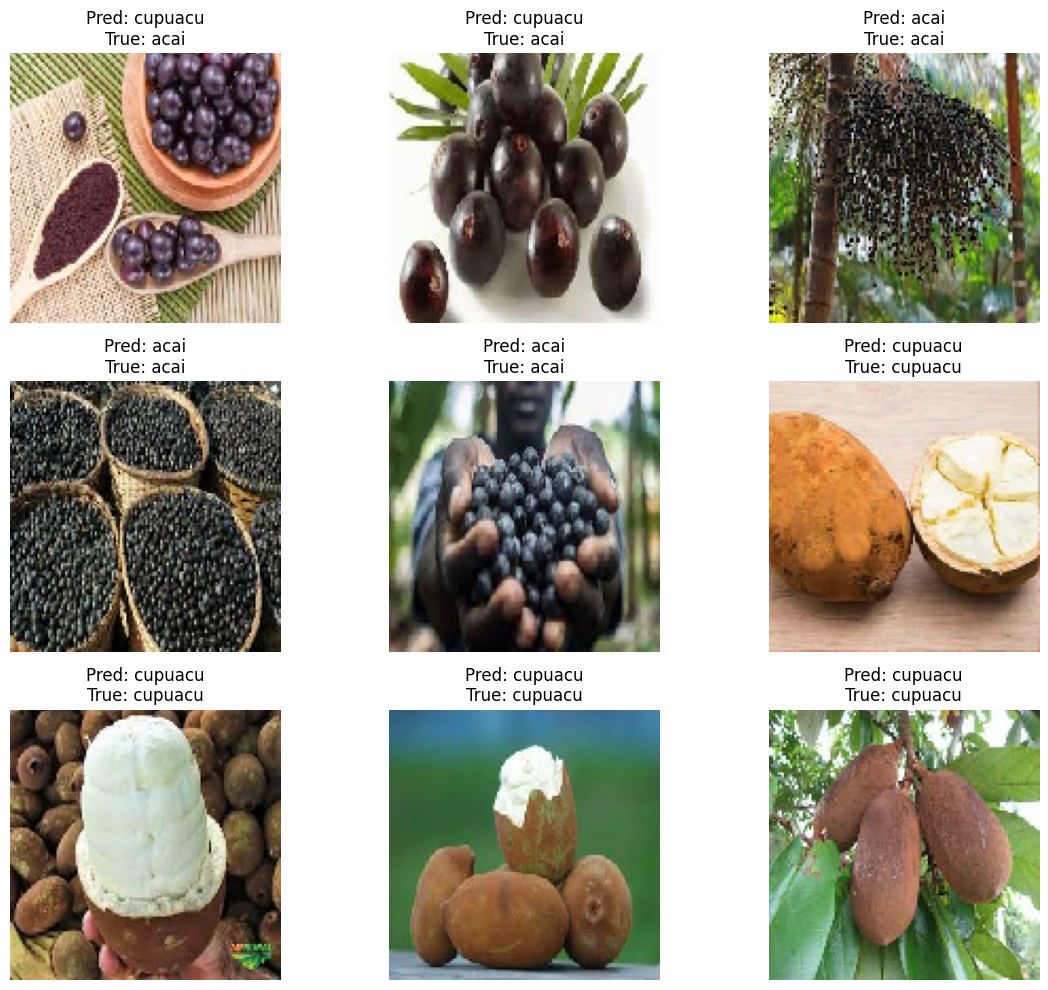

In [55]:
plt.figure(figsize=(12, 10))

for images, labels in test_ds.take(1):
    preds = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(preds, axis=1)

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())

        plt.title(
            f"Pred: {class_names[predicted_labels[i]]}\n"
            f"True: {class_names[labels[i]]}"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

## Conclusion

In this notebook, we successfully:
- Loaded and visualized image data
- Checked and removed corrupted images
- Built training, validation, and test datasets
- Implemented a CNN model using Keras
- Trained the model with callbacks
- Evaluated the model
- Saved and reloaded the model
- Generated predictions and a classification report